In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
train_df = pd.read_csv("cs-training.csv")# Loadind data
test_df = pd.read_csv("cs-test.csv")

In [ ]:
if "Unnamed: 0" in train_df.columns:# removing index column
    train_df.drop(columns=["Unnamed: 0"], inplace=True)
if "Unnamed: 0" in test_df.columns:
    test_df.drop(columns=["Unnamed: 0"], inplace=True)

In [ ]:
target = "SeriousDlqin2yrs" #defining target

X = train_df.drop(columns=[target])
y = train_df[target]

In [ ]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median") #handling missing values using imputation techniques
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Drop the target column from test_df before imputation to match the features X was fitted on
test_features_df = test_df.drop(columns=[target], errors='ignore')
test_imputed = pd.DataFrame(imputer.transform(test_features_df), columns=test_features_df.columns)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() #feature scaling
X_scaled = scaler.fit_transform(X_imputed)
test_scaled = scaler.transform(test_imputed)

In [ ]:
from sklearn.model_selection import train_test_split #train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
from sklearn.linear_model import LogisticRegression  #using logistic regression
lr_model = LogisticRegression(max_iter=2000)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_valid)
lr_prob = lr_model.predict_proba(X_valid)[:,1]
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

print("\n====== Logistic Regression ======")
print("Accuracy :", accuracy_score(y_valid, lr_pred))
print("Precision:", precision_score(y_valid, lr_pred))
print("Recall   :", recall_score(y_valid, lr_pred))
print("F1 Score :", f1_score(y_valid, lr_pred))
print("ROC-AUC  :", roc_auc_score(y_valid, lr_prob))
print(classification_report(y_valid, lr_pred))


====== Logistic Regression ======
Accuracy : 0.934
Precision: 0.5816993464052288
Recall   : 0.044389027431421445
F1 Score : 0.082483781278962
ROC-AUC  : 0.7143877224246047
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     27995
           1       0.58      0.04      0.08      2005

    accuracy                           0.93     30000
   macro avg       0.76      0.52      0.52     30000
weighted avg       0.91      0.93      0.91     30000



In [ ]:
from sklearn.tree import DecisionTreeClassifier   #using decision tree
dt_model = DecisionTreeClassifier(max_depth=8)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_valid)
dt_prob = dt_model.predict_proba(X_valid)[:,1]

print("\n====== Decision Tree ======")
print("Accuracy :", accuracy_score(y_valid, dt_pred))
print("Precision:", precision_score(y_valid, dt_pred))
print("Recall   :", recall_score(y_valid, dt_pred))
print("F1 Score :", f1_score(y_valid, dt_pred))
print("ROC-AUC  :", roc_auc_score(y_valid, dt_prob))
print(classification_report(y_valid, dt_pred))


====== Decision Tree ======
Accuracy : 0.9353333333333333
Precision: 0.5503875968992248
Recall   : 0.1770573566084788
F1 Score : 0.2679245283018868
ROC-AUC  : 0.8504721764084165
              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27995
           1       0.55      0.18      0.27      2005

    accuracy                           0.94     30000
   macro avg       0.75      0.58      0.62     30000
weighted avg       0.92      0.94      0.92     30000



In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=400, max_depth=14, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_valid)
rf_prob = rf_model.predict_proba(X_valid)[:,1]

In [ ]:
print("\n====== Random Forest ======")
print("Accuracy :", accuracy_score(y_valid, rf_pred))
print("Precision:", precision_score(y_valid, rf_pred))
print("Recall   :", recall_score(y_valid, rf_pred))
print("F1 Score :", f1_score(y_valid, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_valid, rf_prob))
print(classification_report(y_valid, rf_pred))


====== Random Forest ======
Accuracy : 0.9373666666666667
Precision: 0.6082474226804123
Recall   : 0.1765586034912718
F1 Score : 0.27367607267104754
ROC-AUC  : 0.868126219546686
              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27995
           1       0.61      0.18      0.27      2005

    accuracy                           0.94     30000
   macro avg       0.78      0.58      0.62     30000
weighted avg       0.92      0.94      0.92     30000



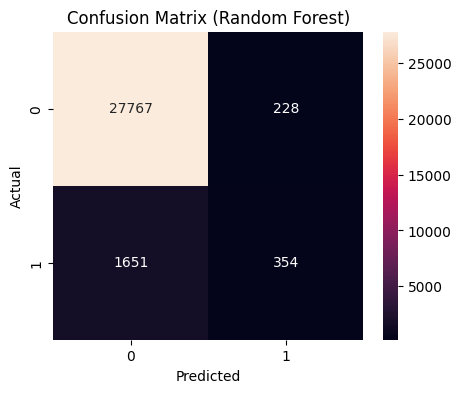

In [ ]:
cm = confusion_matrix(y_valid, rf_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

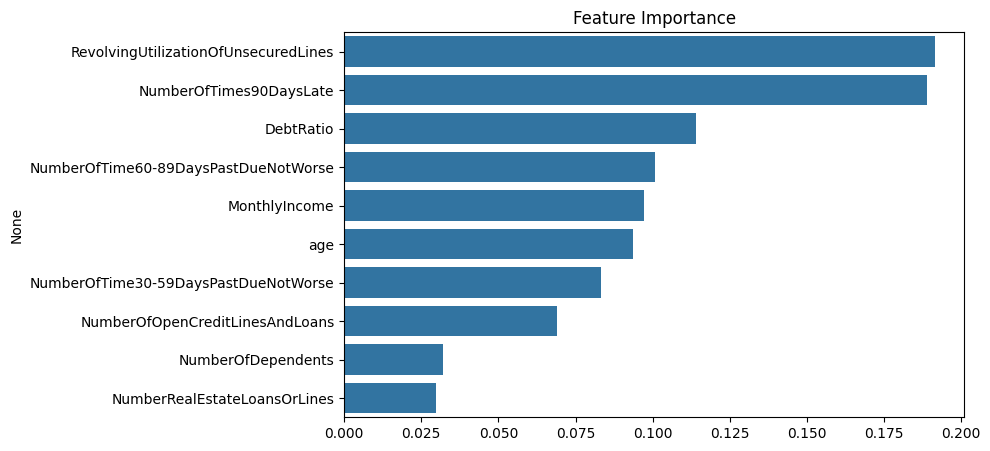


Top Important Features:
 RevolvingUtilizationOfUnsecuredLines    0.191382
NumberOfTimes90DaysLate                 0.188865
DebtRatio                               0.114032
NumberOfTime60-89DaysPastDueNotWorse    0.100812
MonthlyIncome                           0.097314
age                                     0.093597
NumberOfTime30-59DaysPastDueNotWorse    0.083305
NumberOfOpenCreditLinesAndLoans         0.068932
NumberOfDependents                      0.031986
NumberRealEstateLoansOrLines            0.029774
dtype: float64


In [ ]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns) #feature importance
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance")
plt.show()

print("\nTop Important Features:\n", importances.head(10))

In [ ]:
rf_model.fit(X_scaled, y) #trained on full data and predicted test
test_prob = rf_model.predict_proba(test_scaled)[:,1]

submission = pd.DataFrame({
    "Probability_of_Default": test_prob
})

submission.to_csv("credit_risk_predictions.csv", index=False)

print("\n✅ Predictions saved as 'credit_risk_predictions.csv'")


✅ Predictions saved as 'credit_risk_predictions.csv'
